In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
BASE_DIR = Path().resolve().parent
DATA_PATH = BASE_DIR / "data" / "processed" / "final_dataset.csv"

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

In [3]:
df.head(4)

,date,close,volume,return,volatility,interest_rate,inflation,unemployment,gdp
0,2015-01-01,25.949116,5.221054e+09,0.003927,0.024386,0.11,234.747,5.7,18063.529
1,2015-02-01,28.564180,4.546141e+09,0.005144,0.012793,0.11,235.342,5.5,18063.529
2,2015-03-01,27.668077,4.554568e+09,-0.001357,0.013795,0.11,235.976,5.4,18063.529
3,2015-04-01,27.828169,3.984542e+09,0.000348,0.012397,0.12,236.222,5.4,18279.784


In [4]:
print("Dimension of the data")
df.shape

Dimension of the data


(136, 9)

In [5]:
print("Data Types")
df.dtypes

Data Types


date             datetime64[ns]
close                   float64
volume                  float64
return                  float64
volatility              float64
interest_rate           float64
inflation               float64
unemployment            float64
gdp                     float64
dtype: object

In [6]:
df.info

<bound method DataFrame.info of           date       close        volume    return  volatility  interest_rate  \
0   2015-01-01   25.949116  5.221054e+09  0.003927    0.024386           0.11   
1   2015-02-01   28.564180  4.546141e+09  0.005144    0.012793           0.11   
2   2015-03-01   27.668077  4.554568e+09 -0.001357    0.013795           0.11   
3   2015-04-01   27.828169  3.984542e+09  0.000348    0.012397           0.12   
4   2015-05-01   29.089874  3.816608e+09  0.002312    0.013944           0.12   
..         ...         ...           ...       ...         ...            ...   
131 2025-12-01  271.605835  9.245288e+08 -0.001127    0.007463           3.72   
132 2026-01-01  259.237427  1.040017e+09 -0.002251    0.012698           3.64   
133 2026-02-01  264.179993  9.889210e+08  0.001224    0.021947           3.64   
134 2026-03-01  253.789993  9.000357e+08 -0.001754    0.011921           3.64   
135 2026-04-01  270.230011  5.024294e+08  0.005346    0.014934           3.64

In [7]:
import matplotlib.pyplot as plt

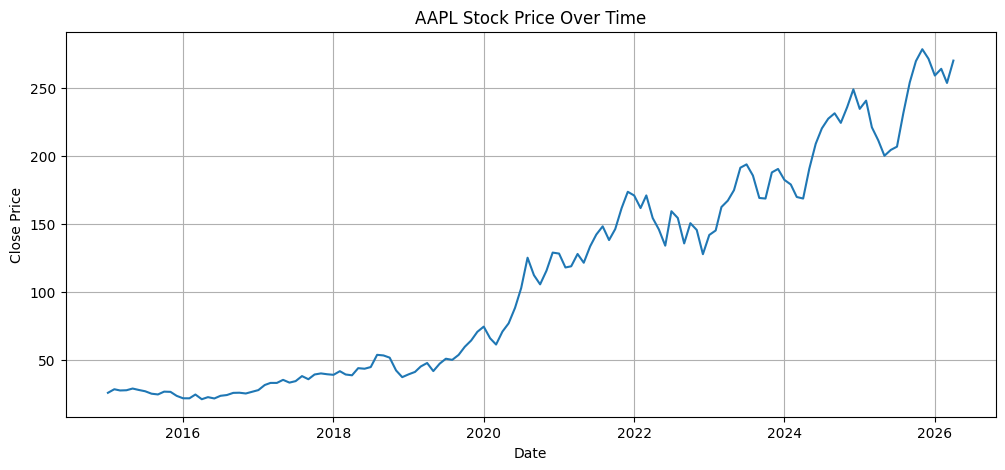

In [8]:
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["close"])
plt.title("AAPL Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid()
plt.show()

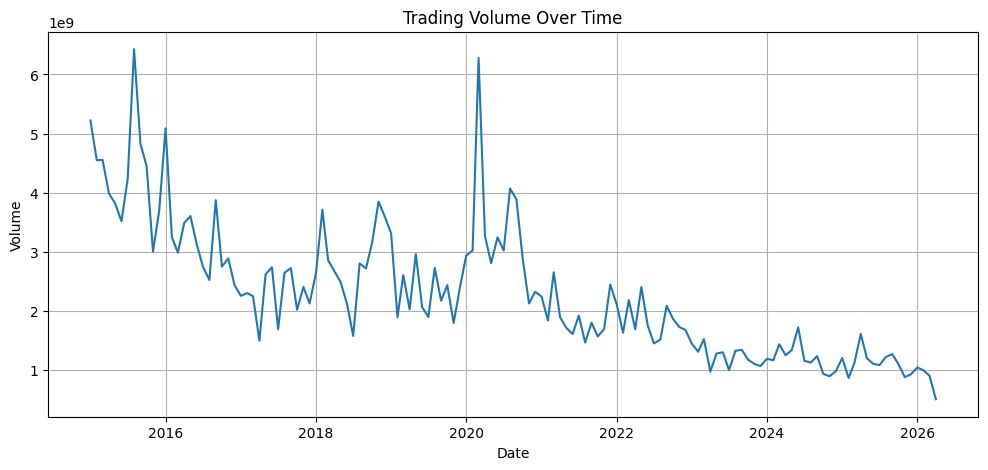

In [9]:
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["volume"])
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid()
plt.show()

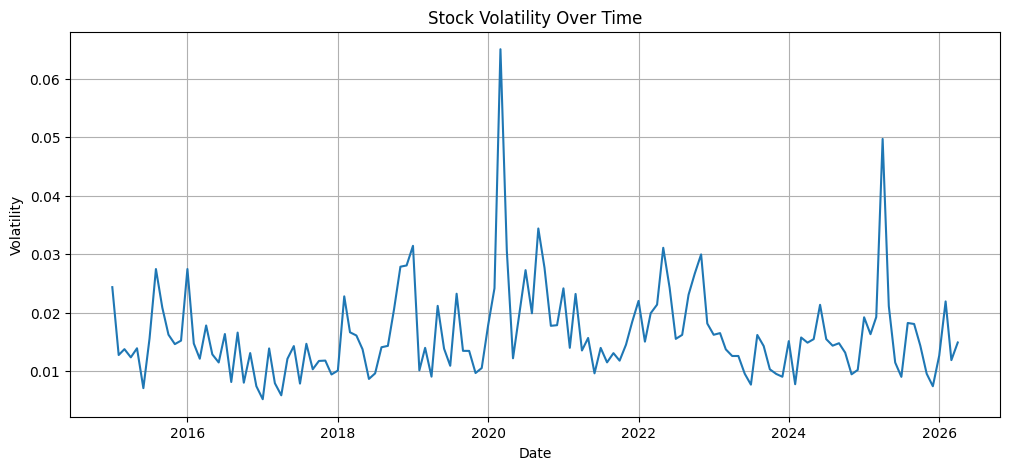

In [10]:
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["volatility"])
plt.title("Stock Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid()
plt.show()

In [11]:
df_corr = df.copy()

df_corr["stock_return"] = df_corr["close"].pct_change()
df_corr = df_corr.dropna()

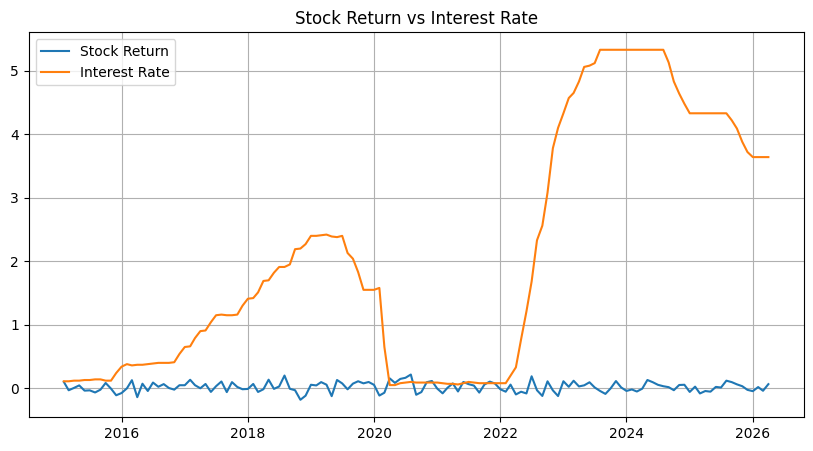

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df_corr["date"], df_corr["stock_return"], label="Stock Return")
plt.plot(df_corr["date"], df_corr["interest_rate"], label="Interest Rate")

plt.title("Stock Return vs Interest Rate")
plt.legend()
plt.grid()
plt.show()

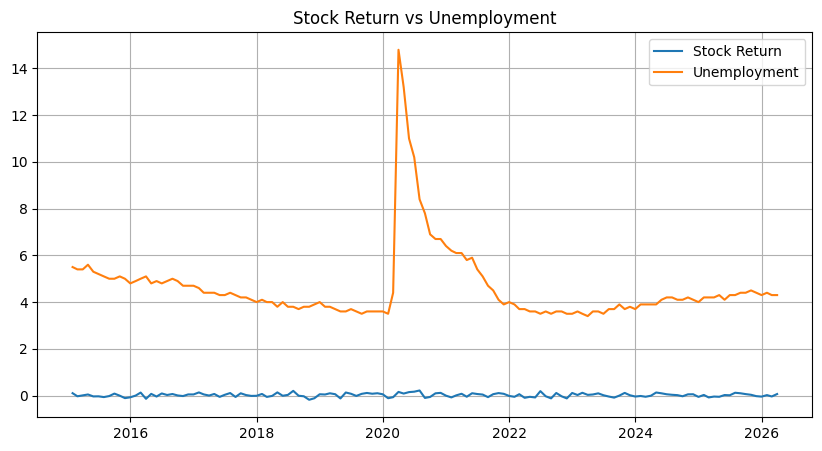

In [13]:
plt.figure(figsize=(10,5))

plt.plot(df_corr["date"], df_corr["stock_return"], label="Stock Return")
plt.plot(df_corr["date"], df_corr["unemployment"], label="Unemployment")

plt.title("Stock Return vs Unemployment")
plt.legend()
plt.grid()
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler

df_norm = df.copy()

cols = ["return", "interest_rate", "inflation", "unemployment", "gdp"]

scaler = StandardScaler()
df_norm[cols] = scaler.fit_transform(df_norm[cols])

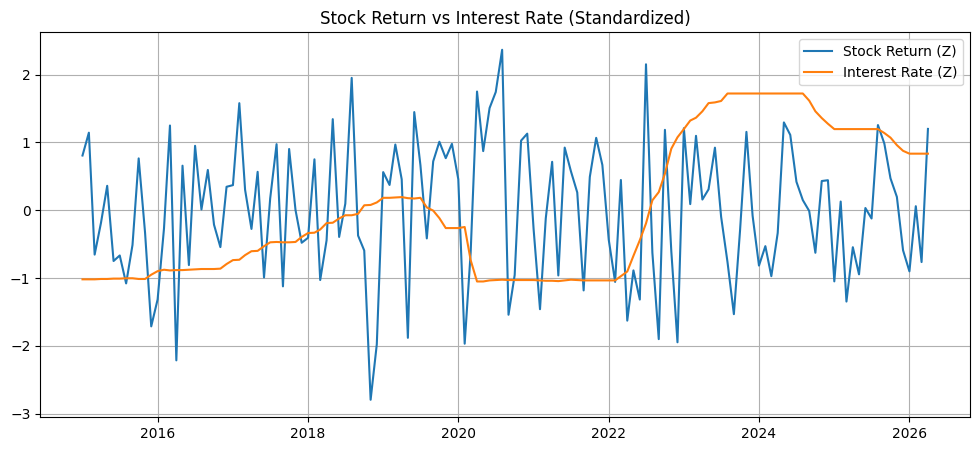

In [15]:
plt.figure(figsize=(12,5))
plt.plot(df_norm["date"], df_norm["return"], label="Stock Return (Z)")
plt.plot(df_norm["date"], df_norm["interest_rate"], label="Interest Rate (Z)")

plt.title("Stock Return vs Interest Rate (Standardized)")
plt.legend()
plt.grid()
plt.show()

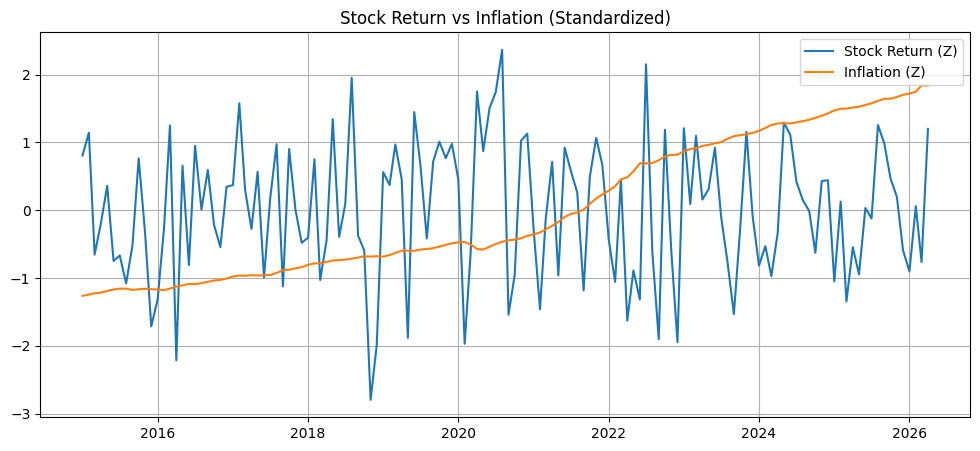

In [16]:
plt.figure(figsize=(12,5))
plt.plot(df_norm["date"], df_norm["return"], label="Stock Return (Z)")
plt.plot(df_norm["date"], df_norm["inflation"], label="Inflation (Z)")

plt.title("Stock Return vs Inflation (Standardized)")
plt.legend()
plt.grid()
plt.show()

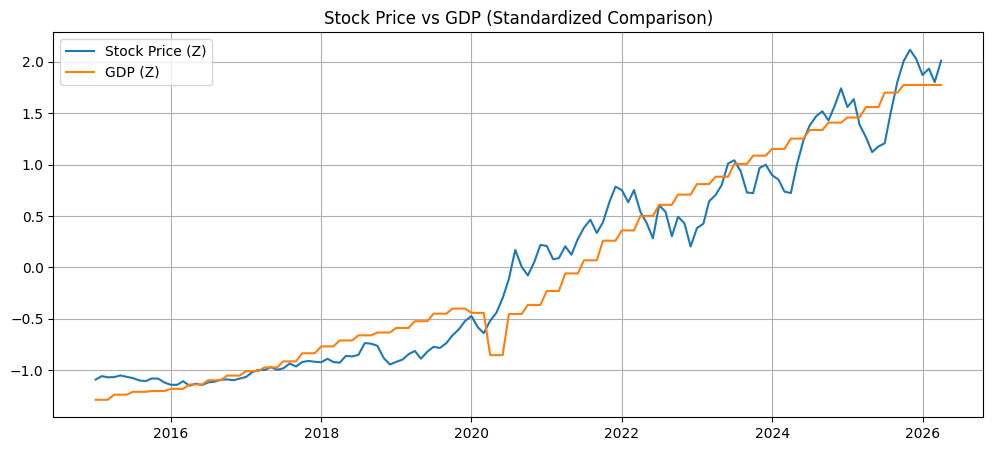

In [17]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df_plot = df.copy()

# Convert GDP + stock to same scale
cols = ["close", "gdp"]

scaler = StandardScaler()
df_plot[cols] = scaler.fit_transform(df_plot[cols])

plt.figure(figsize=(12,5))

plt.plot(df_plot["date"], df_plot["close"], label="Stock Price (Z)")
plt.plot(df_plot["date"], df_plot["gdp"], label="GDP (Z)")

plt.title("Stock Price vs GDP (Standardized Comparison)")
plt.legend()
plt.grid()
plt.show()